# Algoritmo KNN en Clasificación
Usaremos el conjunto de datos *lend_prediction* para explicar los conceptos de preprocesamiento de datos.

Las columnas (predictores) del datasets son:
* Loan_ID: ID_préstamo
* Gender: Género
* Married: Casado
* Dependents: Familiares Dependientes
* Education: Educación
* Self_Employed: Trabajadores por cuenta propia
* ApplicantIncome: Ingresos del solicitante
* CoapplicantIncome: CosolicitanteIngresos
* LoanAmount: Monto del préstamo
* Loan_Amount_Term: Plazo_monto_préstamo
* Credit_History
* Property_Area

El TAG de salida predice y si se entrega un préstamo o no.

Tareas a realizar:
1. Plantee un algoritmo KNN de clasificación.
2. Indique el valor de K óptimo.
3. Primero instancie KNN con todos los predictores sin escalarlos.
4. Segundo escale los datos con:
   * MinMaxScaler.
   * MaxAbsScaler.
   * StandardScaler.
   * RobustScaler.
5. Compare los resultados.
6. Ejercicio optativo. Vuelva a calcular el K óptimo pero ahora con todos los predictores escalados.

In [ ]:
import pandas as pd
# Librería a importar
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MaxAbsScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler


In [ ]:
# Ayuda

# Para cargar el datasets
X_train=pd.read_csv('/content/X_train.csv')
y_train=pd.read_csv('/content/Y_train.csv')
X_test=pd.read_csv('/content/X_test.csv')
y_test=pd.read_csv('/content/Y_test.csv')


In [ ]:
# Seleccionar los predictores
X_train = X_train[['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','Credit_History']]

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(384, 5)
(96, 12)
(384, 1)
(96, 1)


In [ ]:
X_test = X_test[['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','Credit_History']]

In [ ]:
# Intanciando el objeto KNN
knn = KNeighborsClassifier(n_neighbors=5)

# Entrenar el modelo
knn.fit(X_train,y_train.values.ravel())

# Calcular el accuracy score
print("\nAccuracy score on test set :", accuracy_score(y_test,knn.predict(X_test)))


Accuracy score on test set : 0.6145833333333334


Código para graficar el error de train y test

In [ ]:
# Definimos las listas vacias para los valores de accuracy deseados
lista_accuracy_train = []
lista_accuracy_test = []

# Definimos la lista de valores de k que vamos a explorar
k_vecinos = [1,2,3,4,5,6,7,8,9,10,15,20,25,30,35,40]

# Generamos en loop sobre los distintos valores de k
for k in k_vecinos:

    # Vamos a repetir el siguiente bloque de código

    # Definir el modelo con el valor de vecinos deseado
    clf = KNeighborsClassifier(n_neighbors=k)

    # Entrenar el modelo
    clf.fit(X_train,y_train.values.ravel())

    # Predecir y evaluar sobre el set de entrenamiento
    y_train_pred = clf.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)

    # Predecir y evaluar sobre el set de evaluación
    y_test_pred = clf.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)

    # Agregar la información a las listas
    lista_accuracy_train.append(train_acc)
    lista_accuracy_test.append(test_acc)

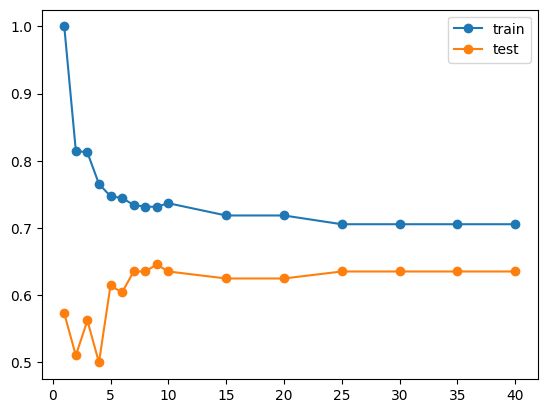

In [ ]:
import matplotlib.pyplot as plt

plt.plot(k_vecinos,lista_accuracy_train,'o-',label='train' )
plt.plot(k_vecinos,lista_accuracy_test,'o-',label='test')
plt.legend()

**1.- MinMaxScaler**

In [ ]:
#Creo una instancia
MMScaler = MinMaxScaler()
#Escalo la variable original
X_train_mms = MMScaler.fit_transform(X_train)
X_test_mms = MMScaler.transform(X_test)

In [ ]:
print(X_train_mms.shape)
print(X_test_mms.shape)

(384, 5)
(96, 5)


In [ ]:
import numpy as np
# Encontrar el valor mínimo y máximo de la variable escalada
valor_minimo = np.min(X_train_mms)
print(valor_minimo)

# Encontrar el valor máximo
valor_maximo = np.max(X_test_mms)
print(valor_maximo)

0.0
1.0


In [ ]:
# Intanciando el objeto KNN
knn_mms = KNeighborsClassifier(n_neighbors=5)

# Entrenar el modelo
knn_mms.fit(X_train_mms,y_train.values.ravel())

# Calcular el accuracy score
print("\nAccuracy score on test set :", accuracy_score(y_test,knn_mms.predict(X_test_mms)))


Accuracy score on test set : 0.75


In [ ]:
# Definimos las listas vacias para los valores de accuracy deseados
lista_accuracy_train = []
lista_accuracy_test = []

# Definimos la lista de valores de k que vamos a explorar
k_vecinos = [1,2,3,4,5,6,7,8,9,10,15,20,25,30,35,40]

# Generamos en loop sobre los distintos valores de k
for k in k_vecinos:

    # Vamos a repetir el siguiente bloque de código

    # Definir el modelo con el valor de vecinos deseado
    clf = KNeighborsClassifier(n_neighbors=k)

    # Entrenar el modelo
    clf.fit(X_train_mms,y_train.values.ravel())

    # Predecir y evaluar sobre el set de entrenamiento
    y_train_pred = clf.predict(X_train_mms)
    train_acc = accuracy_score(y_train, y_train_pred)

    # Predecir y evaluar sobre el set de evaluación
    y_test_pred = clf.predict(X_test_mms)
    test_acc = accuracy_score(y_test, y_test_pred)

    # Agregar la información a las listas
    lista_accuracy_train.append(train_acc)
    lista_accuracy_test.append(test_acc)

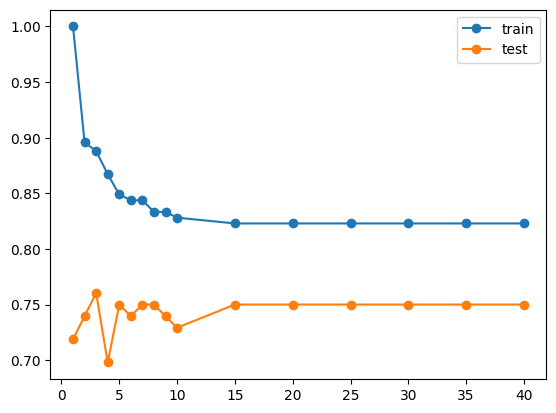

In [ ]:
plt.plot(k_vecinos,lista_accuracy_train,'o-',label='train' )
plt.plot(k_vecinos,lista_accuracy_test,'o-',label='test')
plt.legend()

En el gráfico podemos observar que para el escalador MinMaxScaler el k optimo podría estar en 15

**2.- MaxAbsScaler**

In [ ]:
#Creo una instancia
MAScaler = MaxAbsScaler()
#Escalo la variable original
X_train_mas = MAScaler.fit_transform(X_train)
X_test_mas = MAScaler.transform(X_test)

In [ ]:
import numpy as np
# Encontrar el valor mínimo
valor_minimo = np.min(X_train_mas)
print(valor_minimo)

# Encontrar el valor máximo
valor_maximo = np.max(X_train_mas)
print(valor_maximo)

0.0
1.0


In [ ]:
# Intanciando el objeto KNN
knn_mas = KNeighborsClassifier(n_neighbors=5)

# Entrenar el modelo
knn_mas.fit(X_train_mas,y_train.values.ravel())

# Calcular el accuracy score
print("\nAccuracy score on test set :", accuracy_score(y_test,knn_mas.predict(X_test_mas)))


Accuracy score on test set : 0.75


In [ ]:
# Definimos las listas vacias para los valores de accuracy deseados
lista_accuracy_train = []
lista_accuracy_test = []

# Definimos la lista de valores de k que vamos a explorar
k_vecinos = [1,2,3,4,5,6,7,8,9,10,15,20,25,30,35,40]

# Generamos en loop sobre los distintos valores de k
for k in k_vecinos:

    # Vamos a repetir el siguiente bloque de código

    # Definir el modelo con el valor de vecinos deseado
    clf = KNeighborsClassifier(n_neighbors=k)

    # Entrenar el modelo
    clf.fit(X_train_mas,y_train.values.ravel())

    # Predecir y evaluar sobre el set de entrenamiento
    y_train_pred = clf.predict(X_train_mas)
    train_acc = accuracy_score(y_train, y_train_pred)

    # Predecir y evaluar sobre el set de evaluación
    y_test_pred = clf.predict(X_test_mas)
    test_acc = accuracy_score(y_test, y_test_pred)

    # Agregar la información a las listas
    lista_accuracy_train.append(train_acc)
    lista_accuracy_test.append(test_acc)

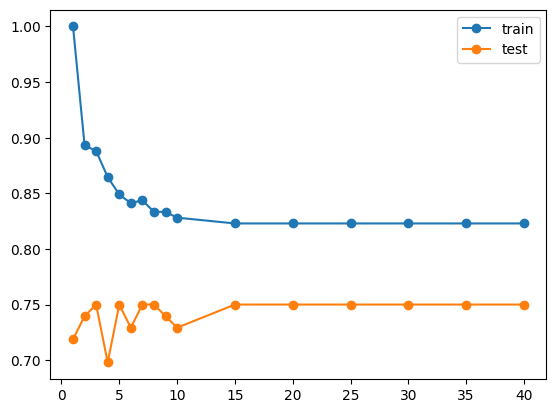

In [ ]:
plt.plot(k_vecinos,lista_accuracy_train,'o-',label='train' )
plt.plot(k_vecinos,lista_accuracy_test,'o-',label='test')
plt.legend()

En el gráfico podemos observar que para el escalador MaxAbsScaler el k optimo podría estar en 15

**3.-StandarScaler**

In [ ]:
escalador_ss = StandardScaler()

In [ ]:
#se hacen copias de los datasets
X_train_ss = X_train
X_test_ss = X_test

In [ ]:
# se escalan los datos
X_train_ss_escalados = escalador_ss.fit_transform(X_train_ss)
X_test_ss_escalados = escalador_ss.transform(X_test_ss)

In [ ]:
# Intanciando el objeto KNN
knn_ss = KNeighborsClassifier(n_neighbors=5)
knn_ss.fit(X_train_ss_escalados,y_train.values.ravel())
print("\nAccuracy score on test set :", accuracy_score(y_test,knn_ss.predict(X_test_ss_escalados)))


Accuracy score on test set : 0.75


In [ ]:
# Definimos las listas vacias para los valores de accuracy deseados
lista_accuracy_train = []
lista_accuracy_test = []

# Definimos la lista de valores de k que vamos a explorar
k_vecinos = [1,2,3,4,5,6,7,8,9,10,15,20,25,30,35,40]

# Generamos en loop sobre los distintos valores de k
for k in k_vecinos:

    # Vamos a repetir el siguiente bloque de código

    # Definir el modelo con el valor de vecinos deseado
    clf = KNeighborsClassifier(n_neighbors=k)

    # Entrenar el modelo
    clf.fit(X_train_ss_escalados,y_train.values.ravel())

    # Predecir y evaluar sobre el set de entrenamiento
    y_train_pred = clf.predict(X_train_ss_escalados)
    train_acc = accuracy_score(y_train, y_train_pred)

    # Predecir y evaluar sobre el set de evaluación
    y_test_pred = clf.predict(X_test_ss_escalados)
    test_acc = accuracy_score(y_test, y_test_pred)

    # Agregar la información a las listas
    lista_accuracy_train.append(train_acc)
    lista_accuracy_test.append(test_acc)

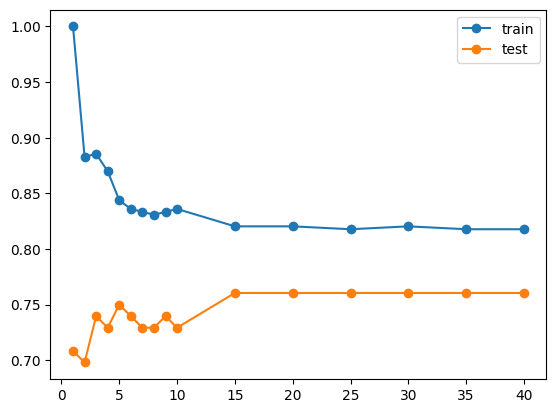

In [ ]:
plt.plot(k_vecinos,lista_accuracy_train,'o-',label='train' )
plt.plot(k_vecinos,lista_accuracy_test,'o-',label='test')
plt.legend()

En el gráfico podemos observar que para el escalador StandarScaler el k optimo podría estar en 15

**4.- RobustScaler**

In [ ]:
escalador_rs = RobustScaler()

In [ ]:
X_train_rs = X_train
X_test_rs = X_test

In [ ]:
# se escalan los datos
X_train_rs_escalados = escalador_rs.fit_transform(X_train_rs)
X_test_rs_escalados = escalador_rs.transform(X_test_rs)

In [ ]:
knn.fit(X_train_rs_escalados,y_train.values.ravel())

KNeighborsClassifier()

In [ ]:
print("\nAccuracy score on test set :", accuracy_score(y_test,knn.predict(X_test_rs_escalados)))


Accuracy score on test set : 0.7291666666666666


In [ ]:
#Definimos las listas vacias para los valores de accuracy deseados
lista_accuracy_train = []
lista_accuracy_test = []

# Definimos la lista de valores de k que vamos a explorar
k_vecinos = [1,2,3,4,5,6,7,8,9,10,15,20,25,30,35,40]
# Generamos en loop sobre los distintos valores de k
for k in k_vecinos:

    # Vamos a repetir el siguiente bloque de código

    # Definir el modelo con el valor de vecinos deseado
    clf = KNeighborsClassifier(n_neighbors=k)

    # Entrenar el modelo
    clf.fit(X_train_ss_escalados,y_train.values.ravel())

    # Predecir y evaluar sobre el set de entrenamiento
    y_train_pred = clf.predict(X_train_rs_escalados)
    train_acc = accuracy_score(y_train, y_train_pred)
# Predecir y evaluar sobre el set de evaluación
    y_test_pred = clf.predict(X_test_rs_escalados)
    test_acc = accuracy_score(y_test, y_test_pred)

    # Agregar la información a las listas
    lista_accuracy_train.append(train_acc)
    lista_accuracy_test.append(test_acc)

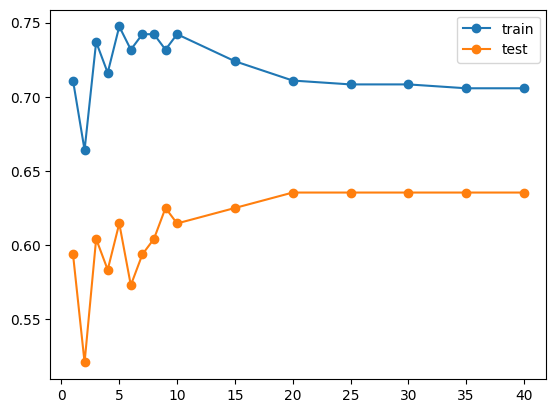

In [ ]:
plt.plot(k_vecinos,lista_accuracy_train,'o-',label='train' )
plt.plot(k_vecinos,lista_accuracy_test,'o-',label='test')
plt.legend()

En el gráfico podemos observar que para el escalador MinMaxScaler el k optimo podría estar en 20

**Conclusiones:**

Los resultados del "Accuracy score" exactitud del set de prueba son:

*   Sin escalado: 0.6145833333333334
*   Usando MinMaxScaler: 0.75
*   Usando MaxAbsoluteScaler: 0.75
*   Usando StandarScaler: 0.75
*   Usando RobustScaler: 0.7291666666666666

Podemos observar que el "Accuracy score" para el dataset escalado tiene un mejor comportamiento frente a los datos sin escalar.

Esto se debe a que el algoritmo de K-vecinos más cercanos se basa en la distancia entre puntos de datos para hacer predicciones. Debido a esto, es crucial escalar los predictores para asegurar que cada uno contribuya de manera equitativa a la medida de la distancia.





**Adicional**
En cada uno de los gráficos identificamos el valor de k óptimo y volvemos a entrenar el modelo usando los k óptimos

**A.1.- MinMaxScaler con k = 15**

In [ ]:
# Intanciando el objeto KNN
knn_mms = KNeighborsClassifier(n_neighbors=15)

# Entrenar el modelo
knn_mms.fit(X_train_mms,y_train.values.ravel())

# Calcular el accuracy score
print("\nAccuracy score MinMaxScaler del dataset de prueba:", accuracy_score(y_test,knn_mms.predict(X_test_mms)))


Accuracy score MinMaxScaler del dataset de prueba: 0.75


**A.2.- MaxAbsScaler con k = 15**

In [ ]:
# Intanciando el objeto KNN
knn_mas = KNeighborsClassifier(n_neighbors=15)

# Entrenar el modelo
knn_mas.fit(X_train_mas,y_train.values.ravel())

# Calcular el accuracy score
print("\nAccuracy score MaxAbsoluteScaler del dataset de prueba:", accuracy_score(y_test,knn_mas.predict(X_test_mas)))


Accuracy score MaxAbsoluteScaler del dataset de prueba: 0.75


**A.3.- StandarScaler con k = 15**

In [ ]:
# Intanciando el objeto KNN
knn_ss = KNeighborsClassifier(n_neighbors=15)
knn_ss.fit(X_train_ss_escalados,y_train.values.ravel())
print("\nAccuracy score StandarScaler del dataset de prueba :", accuracy_score(y_test,knn_ss.predict(X_test_ss_escalados)))


Accuracy score StandarScaler del dataset de prueba : 0.7604166666666666


**A.4.- RobustScaler con k = 20**

In [ ]:
# Intanciando el objeto KNN
knn_rs = KNeighborsClassifier(n_neighbors=20)
knn_rs.fit(X_train_rs_escalados,y_train.values.ravel())
print("\nAccuracy score RobustScaler del dataset de prueba :", accuracy_score(y_test,knn_rs.predict(X_test_rs_escalados)))


Accuracy score RobustScaler del dataset de prueba : 0.7083333333333334


Observamos que para los escaladores MinMaxScaler y MaxAbsScaler no cambió la exactitud cuando usamos el k óptimo porque estos escaladores no afectan significativamente la distribución de los datos en términos de varianza y sesgo, manteniendo las relaciones relativas entre los valores de las características.

Para el StandarScaler vemos que mejoró en un centésimo porque la estandarización puede ayudar a mejorar la distancia euclidiana calculada entre los puntos.

Para el RobustScaler empeoró en un centésimo porque este escalador utiliza la mediana y los cuartiles para escalar los datos, haciéndolo más robusto a los outliers pero puede no ser tan efectivo en datasets donde la distribución de las características es relativamente normal y sin outliers significativos.